# ScoreCard 评分卡模型完整开发流程演示

本示例演示使用 hscredit.xlsx 真实信贷数据进行评分卡模型开发的完整流程

**标签定义**：MOB1 > 15 为坏客户(1)，否则为好客户(0)  
**注意**：MOB2 作为表现期标签，不入模

## 1. 环境初始化

In [1]:
import sys
sys.path.insert(0, '/Users/xiaoxi/CodeBuddy/hscredit/hscredit')

from hscredit.utils import init_setting
init_setting(seed=42)
print('环境初始化完成！')

环境初始化完成！


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from hscredit.core.binning import OptimalBinning
from hscredit.core.selectors import (
    NullSelector, VarianceSelector, ModeSelector,
    CorrSelector, IVSelector, StepwiseSelector
)
from hscredit.core.models import LogisticRegression, ScoreCard
from hscredit.core.metrics import KS, AUC
from hscredit.core.viz import bin_plot, corr_plot, ks_plot, hist_plot, plot_weights
from hscredit.report import feature_bin_stats

print('所有模块导入完成！')

所有模块导入完成！


## 2. 数据加载与探索

In [3]:
data_path = '/Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/utils/hscredit.xlsx'
df = pd.read_excel(data_path)

print(f'数据集形状: {df.shape}')
print(f'\n列名: {list(df.columns)}')
df.head()

数据集形状: (22729, 10)

列名: ['MOB1', 'MOB2', '青云24', '游昆定制分80', '百融定制分V9', '中智小牛分C3', '度小满欺诈因子V6PRO多头版', '百行百川分FPV1', '设备黑名单', '放款期数']


,MOB1,MOB2,青云24,游昆定制分80,百融定制分V9,中智小牛分C3,度小满欺诈因子V6PRO多头版,百行百川分FPV1,设备黑名单,放款期数
0,0,0,612.0000,718.0000,914.7400,687.0000,NaN,NaN,2.0000,6
1,0,0,640.0000,718.0000,894.2800,774.0000,NaN,NaN,3.0000,6
2,0,0,581.0000,709.0000,822.1200,629.0000,53.3800,306.0000,3.0000,6
3,0,0,650.0000,718.0000,794.5000,662.0000,48.6500,285.0000,3.0000,6
4,0,0,650.0000,718.0000,794.5000,662.0000,48.6500,285.0000,3.0000,6


## 3. 特征工程与标签定义

In [4]:
df['target'] = (df['MOB1'] > 15).astype(int)
print('目标标签分布:')
print(df['target'].value_counts(normalize=True))
print(f'\n逾期率: {df["target"].mean():.2%}')
mob2 = df['MOB2'].copy()

目标标签分布:
target
0   0.9293
1   0.0707
Name: proportion, dtype: float64

逾期率: 7.07%


In [5]:
print('生成衍生特征...')
exclude_cols = ['MOB1', 'MOB2', 'target']
base_features = [col for col in df.columns if col not in exclude_cols]

df['feat_ratio_1'] = df['青云24'] / (df['游昆定制分80'] + 1e-8)
df['feat_ratio_2'] = df['百融定制分V9'] / (df['中智小牛分C3'] + 1e-8)
df['feat_ratio_3'] = df['百行百川分FPV1'] / (df['度小满欺诈因子V6PRO多头版'] + 1e-8)

df['feat_diff_1'] = df['百融定制分V9'] - df['百行百川分FPV1']
df['feat_diff_2'] = df['青云24'] - df['游昆定制分80']

df['feat_weighted_1'] = 0.4 * df['百融定制分V9'] + 0.3 * df['百行百川分FPV1'] + 0.3 * df['中智小牛分C3']
df['feat_weighted_2'] = 0.5 * df['青云24'] + 0.5 * df['游昆定制分80']

df['feat_interact_1'] = df['百融定制分V9'] * df['设备黑名单']
df['feat_interact_2'] = df['青云24'] * df['放款期数']

score_cols = ['青云24', '游昆定制分80', '百融定制分V9', '中智小牛分C3', '百行百川分FPV1']
df['feat_mean'] = df[score_cols].mean(axis=1)
df['feat_std'] = df[score_cols].std(axis=1)
df['feat_max'] = df[score_cols].max(axis=1)
df['feat_min'] = df[score_cols].min(axis=1)
df['feat_range'] = df['feat_max'] - df['feat_min']

print(f'特征工程完成，当前特征数: {df.shape[1]}')

生成衍生特征...
特征工程完成，当前特征数: 25


In [6]:
df = df.replace([np.inf, -np.inf], np.nan)
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
print('数据清洗完成')

数据清洗完成


## 4. 数据集划分

In [7]:
feature_cols = [col for col in df.columns if col not in ['MOB1', 'MOB2', 'target']]
X = df[feature_cols]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

mob2_train = mob2.loc[X_train.index]
mob2_test = mob2.loc[X_test.index]

print(f'训练集: {X_train.shape[0]} 条')
print(f'测试集: {X_test.shape[0]} 条')
print(f'训练集逾期率: {y_train.mean():.2%}')
print(f'测试集逾期率: {y_test.mean():.2%}')

训练集: 15910 条
测试集: 6819 条
训练集逾期率: 7.07%
测试集逾期率: 7.07%


## 5. 特征筛选

In [8]:
null_selector = NullSelector(threshold=0.5)
X_train_filtered = null_selector.fit_transform(X_train)
print(f'缺失率筛选后: {X_train_filtered.shape[1]} 个特征')

var_selector = VarianceSelector(threshold=0.01)
X_train_filtered = var_selector.fit_transform(X_train_filtered)
print(f'方差筛选后: {X_train_filtered.shape[1]} 个特征')

mode_selector = ModeSelector(threshold=0.9)
X_train_filtered = mode_selector.fit_transform(X_train_filtered)
print(f'众数筛选后: {X_train_filtered.shape[1]} 个特征')

缺失率筛选后: 22 个特征
方差筛选后: 21 个特征
众数筛选后: 20 个特征


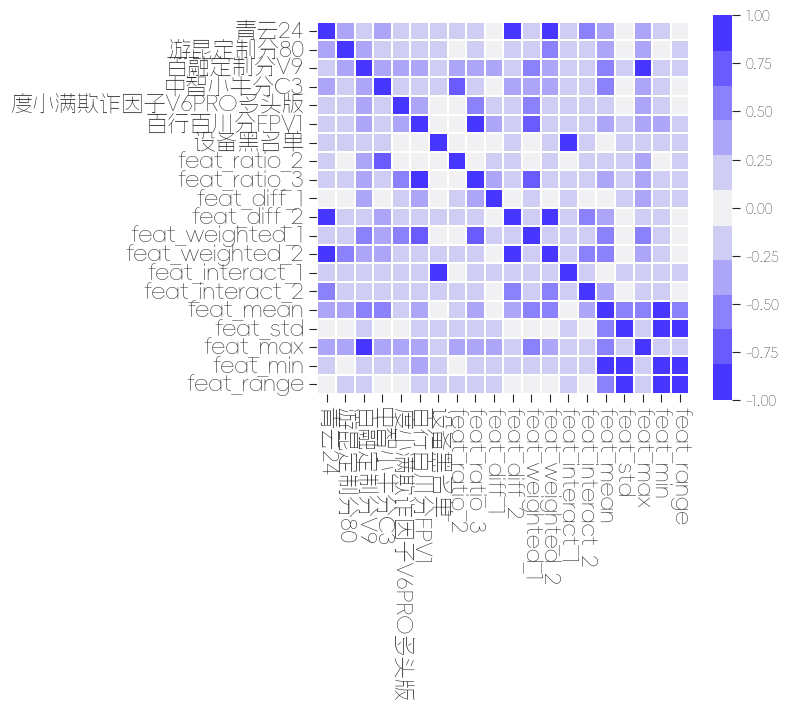

In [9]:
corr_plot(X_train_filtered, figure_size=(6, 5), annot=False);

In [10]:
corr_selector = CorrSelector(threshold=0.9)
X_train_filtered = corr_selector.fit_transform(X_train_filtered, y_train)
print(f'相关性筛选后: {X_train_filtered.shape[1]} 个特征')

相关性筛选后: 13 个特征


In [11]:
binner_temp = OptimalBinning(max_n_bins=5, min_bin_size=0.05, method='mdlp')
binner_temp.fit(X_train_filtered, y_train)
X_train_woe_temp = binner_temp.transform(X_train_filtered, woe=True)

iv_selector = IVSelector(threshold=0.02)
iv_selector.fit(X_train_woe_temp, y_train)
print('IV值筛选结果:')
print(iv_selector.get_scores_df().sort_values('得分', ascending=False))

IV值筛选结果:
                 特征     得分  状态
2           百融定制分V9 0.1824  选中
10  feat_weighted_1 0.1216  选中
5         百行百川分FPV1 0.0886  选中
3           中智小牛分C3 0.0627  选中
12        feat_mean 0.0590  选中
1           游昆定制分80 0.0538  选中
11  feat_interact_2 0.0326  选中
4   度小满欺诈因子V6PRO多头版 0.0318  选中
9       feat_diff_2 0.0317  选中
0        feat_range 0.0000  剔除
6             设备黑名单 0.0000  剔除
7      feat_ratio_2 0.0000  剔除
8       feat_diff_1 0.0000  剔除


In [12]:
X_train_filtered = iv_selector.transform(X_train_filtered)
print(f'IV筛选后: {X_train_filtered.shape[1]} 个特征')

IV筛选后: 9 个特征


In [13]:
X_train_woe_step = binner_temp.transform(X_train_filtered, woe=True)

stepwise_selector = StepwiseSelector(
    estimator='logit', direction='both', criterion='aic', max_features=15
)
stepwise_selector.fit(X_train_woe_step, y_train)

selected_features = stepwise_selector.selected_features_
print(f'逐步回归选中 {len(selected_features)} 个特征')
print(f'选中特征: {selected_features}')

逐步回归选中 6 个特征
选中特征: ['百融定制分V9', 'feat_weighted_1', 'feat_mean', '游昆定制分80', '百行百川分FPV1', 'feat_diff_2']


In [14]:
X_train_final = X_train_filtered[selected_features]
X_test_final = X_test[selected_features]
print(f'最终建模特征数: {len(selected_features)}')

最终建模特征数: 6


## 6. 特征分箱与WOE转换

In [15]:
binner = OptimalBinning(max_n_bins=5, min_bin_size=0.01, method='mdlp')
binner.fit(X_train_final, y_train)
X_train_woe = binner.transform(X_train_final, metric='woe')
X_test_woe = binner.transform(X_test_final, metric='woe')
print('WOE转换完成')
X_train_woe.head()

WOE转换完成


,百融定制分V9,feat_weighted_1,feat_mean,游昆定制分80,百行百川分FPV1,feat_diff_2
1185,0.5627,0.1145,0.0563,0.2012,0.0848,0.1218
22397,0.1157,0.1145,0.0563,0.2012,0.0848,0.1218
1356,0.1157,0.1145,0.0563,-0.2696,0.0848,0.1218
14025,0.5627,0.1145,0.0563,0.2012,0.0848,-0.2634
4125,0.1157,0.1145,0.0563,0.2012,0.0848,-0.2634


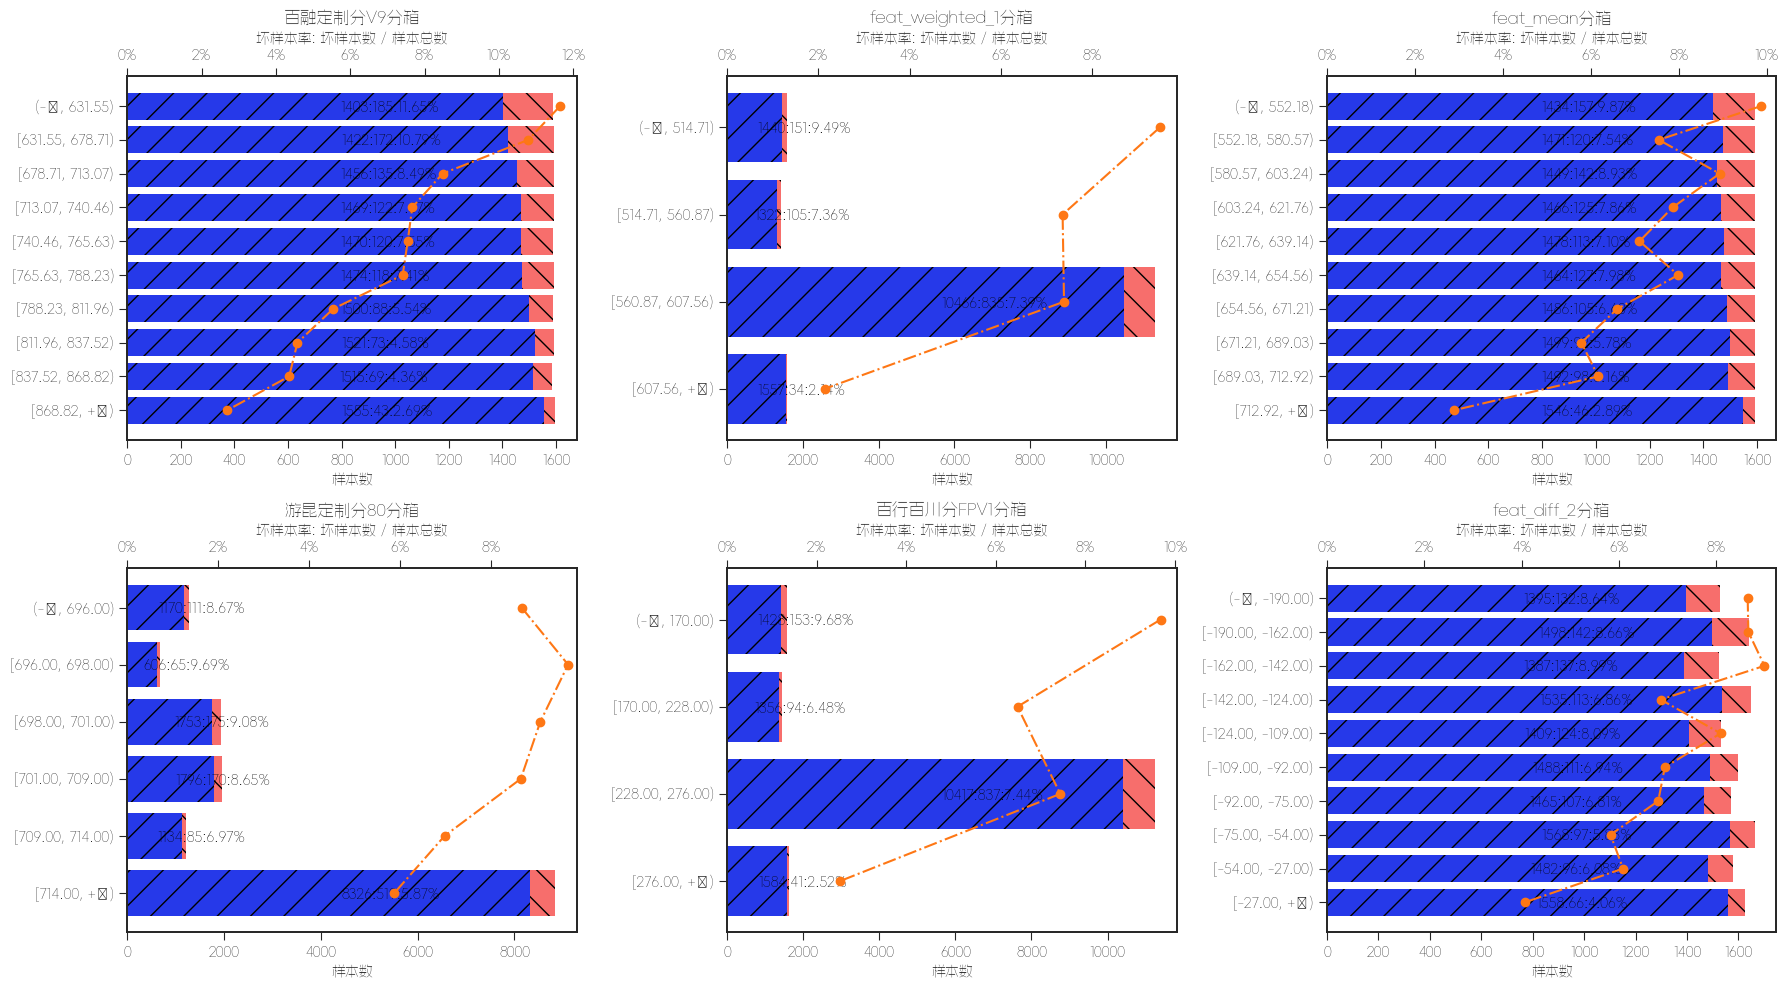

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(selected_features[:6]):
    bin_plot(X_train_final[col], y_train, ax=axes[i], title=f'{col}分箱', figsize=(10, 5))
plt.tight_layout()
plt.show()

## 7. 逻辑回归建模

In [17]:
lr = LogisticRegression(calculate_stats=True, max_iter=1000, C=0.1)
lr.fit(X_train_woe, y_train)

train_proba = lr.predict_proba(X_train_woe)[:, 1]
test_proba = lr.predict_proba(X_test_woe)[:, 1]

print(f'训练集 AUC: {AUC(y_train, train_proba):.4f}, KS: {KS(y_train, train_proba):.4f}')
print(f'测试集 AUC: {AUC(y_test, test_proba):.4f}, KS: {KS(y_test, test_proba):.4f}')

训练集 AUC: 0.6336, KS: 0.2011
测试集 AUC: 0.6382, KS: 0.2143


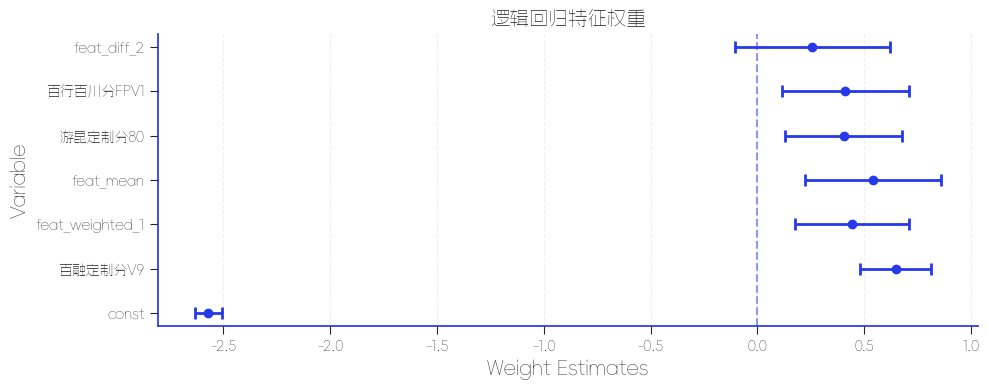

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_weights(lr, ax=ax)
plt.title('逻辑回归特征权重', fontsize=14)
plt.tight_layout()
plt.show()

## 8. 评分卡转换

In [19]:
scorecard = ScoreCard(
    pdo=60, rate=2, base_odds=35, base_score=750,
    lr_model=lr, combiner=binner
)
scorecard.fit(X_train_woe, y_train)
print(f'评分卡转换完成，特征数: {scorecard.n_features_}')

评分卡转换完成，特征数: 6


In [20]:
print('评分卡基础配置:')
scorecard.scorecard_scale()

评分卡基础配置:


,刻度项,刻度值,备注
0,base_odds,35.0000,根据业务经验设置的基础比率（违约概率/正常概率），估算方法：（1-样本坏客户占比）/坏客户占比
1,base_score,750.0000,基础ODDS对应的分数
2,rate,2.0000,设置分数的倍率
3,pdo,60.0000,表示分数增长PDO时，ODDS值增长到RATE倍
4,B,86.5617,补偿值，计算方式：pdo / ln(rate)
5,A,442.2430,刻度，计算方式：base_score - B * ln(base_odds)


In [21]:
scorecard_points = scorecard.scorecard_points()
print(f'评分卡规则共 {len(scorecard_points)} 行')
scorecard_points.head(15)

评分卡规则共 14 行


,变量名称,变量含义,变量分箱,对应分数
0,百融定制分V9,,"[-inf, 661.635)",-31.4800
1,百融定制分V9,,"[661.635, 786.85)",-6.4700
2,百融定制分V9,,"[786.85, 862.605)",19.4000
3,百融定制分V9,,"[862.605, +inf)",58.6000
4,feat_weighted_1,,"[-inf, 582.218)",-4.3800
5,feat_weighted_1,,"[582.218, +inf)",41.9000
6,feat_mean,,"[-inf, 720.7787)",-2.6400
7,feat_mean,,"[720.7787, +inf)",51.3900
8,游昆定制分80,,"[-inf, 716.0)",-7.0200
9,游昆定制分80,,"[716.0, +inf)",9.4100


In [22]:
train_scores = scorecard.predict(X_train_final)
test_scores = scorecard.predict(X_test_final)

print(f'训练集评分范围: [{train_scores.min():.0f}, {train_scores.max():.0f}]')
print(f'测试集评分范围: [{test_scores.min():.0f}, {test_scores.max():.0f}]')
print(f'训练集评分均值: {train_scores.mean():.2f}')
print(f'测试集评分均值: {test_scores.mean():.2f}')

训练集评分范围: [613, 816]
测试集评分范围: [613, 816]
训练集评分均值: 676.14
测试集评分均值: 676.37


## 9. feature_bin_stats分析

In [23]:
train_eval = pd.DataFrame({
    'score': train_scores,
    'MOB1': df.loc[X_train_final.index, 'MOB1'].values,
    'MOB2': mob2_train.values
})
test_eval = pd.DataFrame({
    'score': test_scores,
    'MOB1': df.loc[X_test_final.index, 'MOB1'].values,
    'MOB2': mob2_test.values
})

In [24]:
print('测试集评分分箱统计（MOB1 > 15）')
test_stats = feature_bin_stats(
    test_eval, feature='score', overdue='MOB1', dpds=15,
    method='quantile', max_n_bins=10, margins=True
)
test_stats

测试集评分分箱统计（MOB1 > 15）


,指标名称,指标含义,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,score,score,"(-inf, 638.4864]",1001,890,111,0.1468,0.1404,0.2303,0.1109,0.4945,0.0444,0.3144,1.5688,0.0979,1.5688,0.0979,890,111,0.0898
1,score,score,"(638.4864, 654.9201]",1582,1426,156,0.2320,0.2250,0.3237,0.0986,0.3634,0.0358,0.3144,1.3951,0.1193,1.4624,0.2819,2316,267,0.1885
2,score,score,"(654.9201, 664.3584]",1072,991,81,0.1572,0.1564,0.1681,0.0756,0.0720,0.0008,0.3144,1.0690,0.0129,1.3470,0.4008,3307,348,0.2001
3,score,score,"(664.3584, 726.365]",1791,1682,109,0.2626,0.2654,0.2261,0.0609,-0.1602,0.0063,0.3144,0.8610,-0.0495,1.1872,0.7424,4989,457,0.1609
4,score,score,"(726.365, +inf)",1373,1348,25,0.2013,0.2127,0.0519,0.0182,-1.4113,0.2270,0.3144,0.2576,-0.1872,1.0000,0.0000,6337,482,0.0000
5,score,score,合计,6819,6337,482,1.0000,1.0000,1.0000,0.0707,0.0000,0.0000,0.3144,1.0000,1.0000,1.0000,1.0000,17839,1665,0.2001


In [25]:
print('测试集评分分箱统计（MOB2 > 15，独立验证）')
test_stats_mob2 = feature_bin_stats(
    test_eval, feature='score', overdue='MOB2', dpds=15,
    method='quantile', max_n_bins=10, margins=True
)
test_stats_mob2

测试集评分分箱统计（MOB2 > 15，独立验证）


,指标名称,指标含义,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,score,score,"(-inf, 638.4864]",1001,814,187,0.1468,0.1352,0.2338,0.1868,0.5472,0.0539,0.3206,1.5923,0.1019,1.5923,0.1019,814,187,0.0985
1,score,score,"(638.4864, 654.9201]",1582,1337,245,0.2320,0.2221,0.3063,0.1549,0.3211,0.0270,0.3206,1.3200,0.0967,1.4256,0.2595,2151,432,0.1826
2,score,score,"(654.9201, 664.3584]",1072,939,133,0.1572,0.1560,0.1663,0.1241,0.0636,0.0007,0.3206,1.0575,0.0107,1.3176,0.3669,3090,565,0.1929
3,score,score,"(664.3584, 726.365]",1791,1599,192,0.2626,0.2657,0.2400,0.1072,-0.1016,0.0026,0.3206,0.9138,-0.0307,1.1848,0.7331,4689,757,0.1672
4,score,score,"(726.365, +inf)",1373,1330,43,0.2013,0.2210,0.0537,0.0313,-1.4137,0.2364,0.3206,0.2669,-0.1848,1.0000,0.0000,6019,800,0.0000
5,score,score,合计,6819,6019,800,1.0000,1.0000,1.0000,0.1173,0.0000,0.0000,0.3206,1.0000,1.0000,1.0000,1.0000,16763,2741,0.1929


In [26]:
print('多维度对比（MOB1 vs MOB2，dpd=0 vs dpd=15）')
combined_stats = feature_bin_stats(
    test_eval, feature='score', overdue=['MOB1', 'MOB2'],
    dpds=[0, 15], method='quantile', max_n_bins=8, margins=True
)
combined_stats

多维度对比（MOB1 vs MOB2，dpd=0 vs dpd=15）


分箱详情                                           MOB1_0+                             ... MOB2_15+                                                                 
    指标名称   指标含义                  分箱标签  样本总数   样本占比    好样本数  坏样本数  好样本占比  坏样本占比   坏样本率  ...   分档WOE值  分档IV值  指标IV值  LIFT值    坏账改善 累积LIFT值 累积坏账改善 累积好样本数 累积坏样本数  分档KS值
0  score  score      (-inf, 638.4864]  1001 0.1468     756   245 0.1306 0.2379 0.2448  ...   0.5472 0.0539 0.3206 1.5923  0.1019  1.5923 0.1019    814    187 0.0985
1  score  score  (638.4864, 654.9201]  1582 0.2320    1246   336 0.2152 0.3262 0.2124  ...   0.3211 0.0270 0.3206 1.3200  0.0967  1.4256 0.2595   2151    432 0.1826
2  score  score  (654.9201, 664.3584]  1072 0.1572     913   159 0.1577 0.1544 0.1483  ...   0.0636 0.0007 0.3206 1.0575  0.0107  1.3176 0.3669   3090    565 0.1929
3  score  score   (664.3584, 726.365]  1791 0.2626    1563   228 0.2700 0.2214 0.1273  ...  -0.1016 0.0026 0.3206 0.9138 -0.0307  1.1848 0.7331   4689    757 0.1672
4  score  score       (726.365, +inf)  1373 0.2013    1311    62 0.2265 0.0602 0.0452  ...  -1.4137 0.2364 0.3206 0.2669 -0.1848  1.0000 0.0000   6019    800 0.0000
5  score  score                    合计  6819 1.0000    5789  1030 1.0000 1.0000 0.1173  ...   0.0000 0.0000 0.3206 1.0000  1.0000  1.0000 1.0000  16763   2741 0.0985

[6 rows x 65 columns]

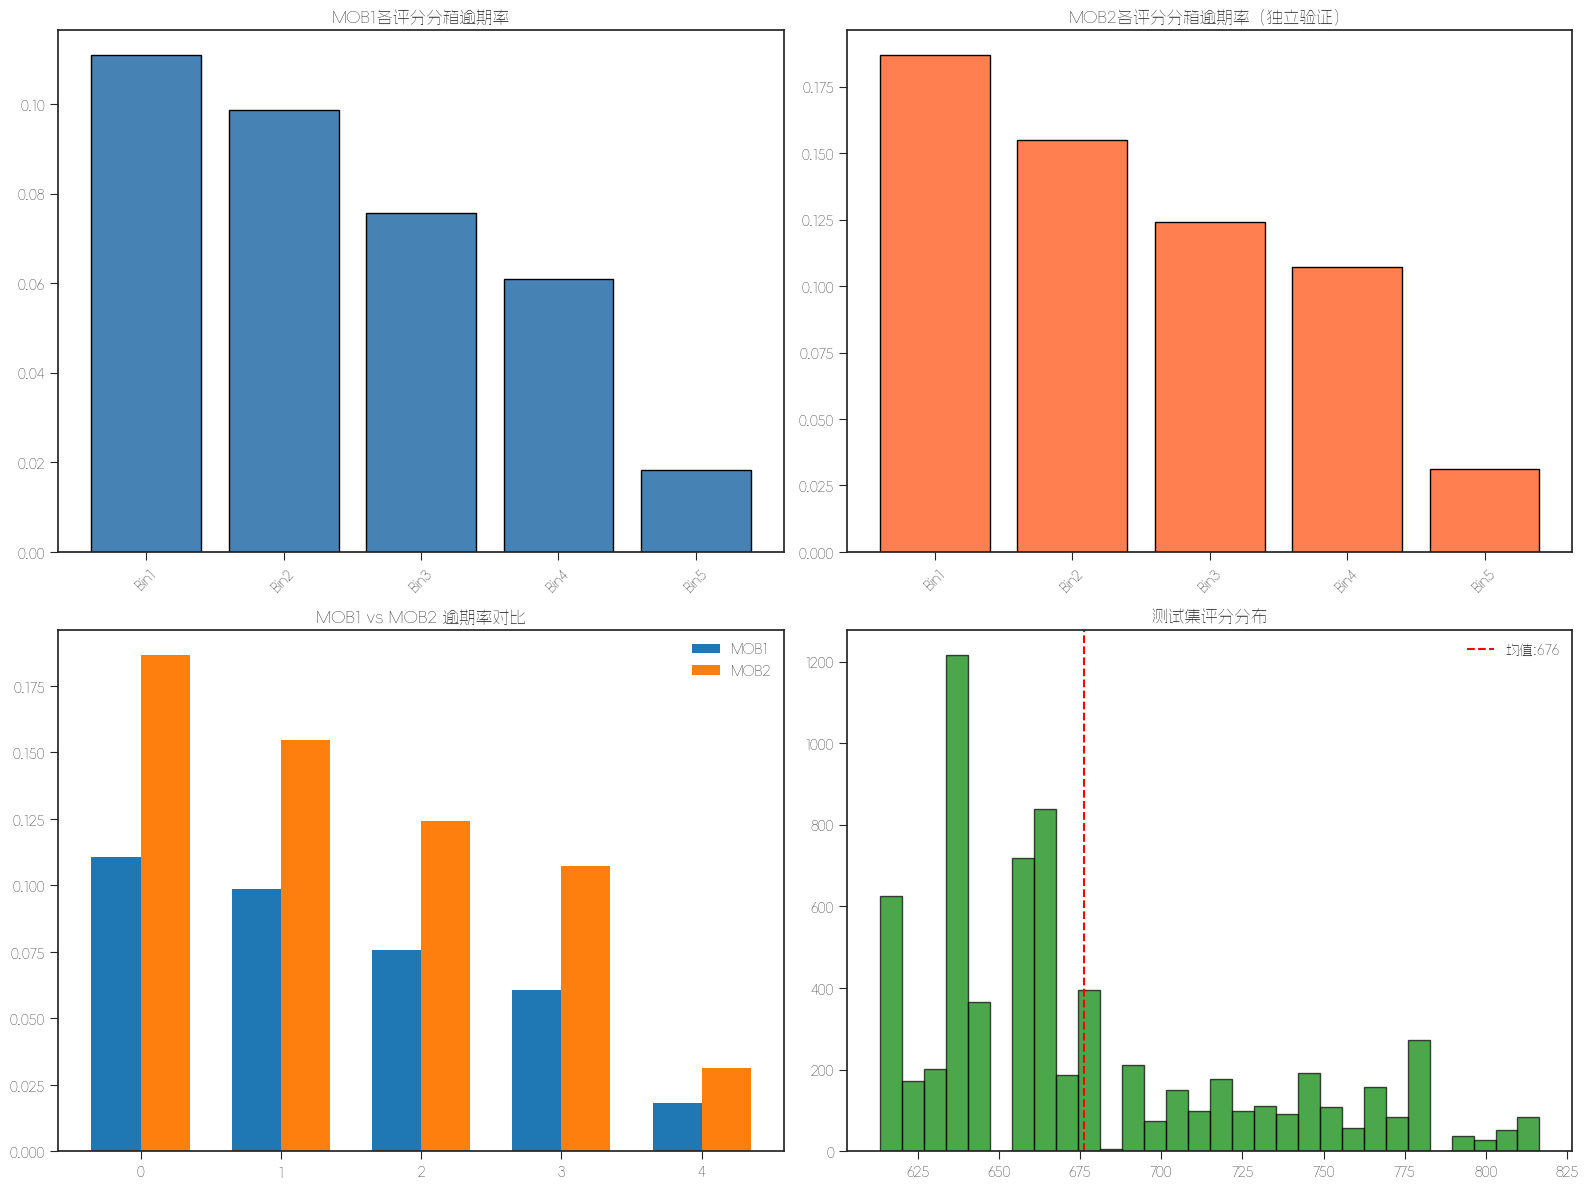

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 检查列名类型，处理多级表头
if isinstance(test_stats.columns, pd.MultiIndex):
    # 多级表头：使用元组访问
    mob1_bad_rate = test_stats.iloc[:-1][('MOB1_15+', '坏样本率')]
else:
    # 单级表头：直接使用列名
    mob1_bad_rate = test_stats.iloc[:-1]['坏样本率']

axes[0,0].bar(range(len(mob1_bad_rate)), mob1_bad_rate, color='steelblue', edgecolor='black')
axes[0,0].set_title('MOB1各评分分箱逾期率')
axes[0,0].set_xticks(range(len(mob1_bad_rate)))
axes[0,0].set_xticklabels([f'Bin{i+1}' for i in range(len(mob1_bad_rate))], rotation=45)

if isinstance(test_stats_mob2.columns, pd.MultiIndex):
    mob2_bad_rate = test_stats_mob2.iloc[:-1][('MOB2_15+', '坏样本率')]
else:
    mob2_bad_rate = test_stats_mob2.iloc[:-1]['坏样本率']

axes[0,1].bar(range(len(mob2_bad_rate)), mob2_bad_rate, color='coral', edgecolor='black')
axes[0,1].set_title('MOB2各评分分箱逾期率（独立验证）')
axes[0,1].set_xticks(range(len(mob2_bad_rate)))
axes[0,1].set_xticklabels([f'Bin{i+1}' for i in range(len(mob2_bad_rate))], rotation=45)

x = np.arange(len(mob1_bad_rate))
width = 0.35
axes[1,0].bar(x - width/2, mob1_bad_rate, width, label='MOB1')
axes[1,0].bar(x + width/2, mob2_bad_rate, width, label='MOB2')
axes[1,0].set_title('MOB1 vs MOB2 逾期率对比')
axes[1,0].set_xticks(x)
axes[1,0].legend()

axes[1,1].hist(test_scores, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1,1].axvline(test_scores.mean(), color='red', linestyle='--', label=f'均值:{test_scores.mean():.0f}')
axes[1,1].set_title('测试集评分分布')
axes[1,1].legend()

plt.tight_layout()
plt.show()

## 10. 评分卡深度分析

In [28]:
score_prob_table = scorecard.score_to_probability_table(
    scores=test_scores, y=y_test.values, n_bins=10, method='quantile'
)
print('评分与逾期率对应表:')
score_prob_table

评分与逾期率对应表:


,评分区间,评分中位数,理论逾期率,理论Odds,样本数,坏样本数,好样本数,实际逾期率,实际Odds,累计样本数,累计坏样本数,累计好样本数,累计样本占比,累计坏样本占比,累计好样本占比,累计KS
0,"[613, 622)",613.4800,12.15%,0.14,798,88,710,11.03%,8.07,798,88,710,11.70%,18.26%,11.20%,11.0174
1,"[622, 638)",638.4900,9.39%,0.10,1327,143,1184,10.78%,8.28,2125,231,1894,31.16%,47.93%,29.89%,29.4107
2,"[638, 655)",654.9200,7.89%,0.09,1174,97,1077,8.26%,11.10,3299,328,2971,48.38%,68.05%,46.88%,46.1995
3,"[655, 664)",663.5000,7.20%,0.08,356,20,336,5.62%,16.80,3655,348,3307,53.60%,72.20%,52.19%,51.4680
4,"[664, 664)",664.3600,7.14%,0.08,485,30,455,6.19%,15.17,4140,378,3762,60.71%,78.42%,59.37%,58.5858
5,"[664, 689)",680.7900,5.98%,0.06,790,49,741,6.20%,15.12,4930,427,4503,72.30%,88.59%,71.06%,70.1741
6,"[689, 726)",710.6400,4.31%,0.05,530,30,500,5.66%,16.67,5460,457,5003,80.07%,94.81%,78.95%,78.0019
7,"[726, 766)",743.4000,2.99%,0.03,680,17,663,2.50%,39.00,6140,474,5666,90.04%,98.34%,89.41%,88.4266
8,"[766, 816)",777.2500,2.04%,0.02,679,8,671,1.18%,83.88,6819,482,6337,100.00%,100.00%,100.00%,99.0000


In [29]:
detailed_scores = scorecard.get_detailed_score(X_test_final.iloc[:3], include_reason=True)
detailed_scores

样本信息                    百融定制分V9                                    feat_weighted_1                           ... 游昆定制分80 百行百川分FPV1                               feat_diff_2                                                                                                            评分分析
    样本索引       总分     截距分数      原始值                 分箱    WOE       分数             原始值               分箱     WOE  ...      分数       原始值             分箱    WOE      分数         原始值             分箱     WOE     分数                                                                              评分原因
0  10707 663.5000 664.7300 752.5500  [661.635, 786.85) 0.1157  -6.4700        560.8660  [-inf, 582.218)  0.1145  ...  9.4100  228.0000  [-inf, 269.5) 0.0848 -3.0200    -20.0000  (-inf, -83.5] -0.2634 5.8700        百融定制分V9提升25.0分(当前-6.5分); 游昆定制分80提升16.4分(当前9.4分); feat_diff_2提升0.0分(当前5.9分)
1  22073 622.0700 664.7300 582.2300    [-inf, 661.635) 0.5627 -31.4800        430.8920  [-inf, 582.218)  0.1145  ... -7.0200   68.0000  [-inf, 269.5) 0.0848 -3.0200    -48.0000  (-inf, -83.5] -0.2634 5.8700       feat_diff_2提升0.0分(当前5.9分); 百行百川分FPV1提升0.0分(当前-3.0分); 游昆定制分80提升0.0分(当前-7.0分)
2    848 709.7800 664.7300 752.3000  [661.635, 786.85) 0.1157  -6.4700        610.5200  [582.218, +inf) -1.0952  ...  9.4100  249.0000  [-inf, 269.5) 0.0848 -3.0200    -58.0000  (-inf, -83.5] -0.2634 5.8700  feat_weighted_1提升46.3分(当前41.9分); 百融定制分V9提升25.0分(当前-6.5分); 游昆定制分80提升16.4分(当前9.4分)

[3 rows x 28 columns]

## 11. 可视化

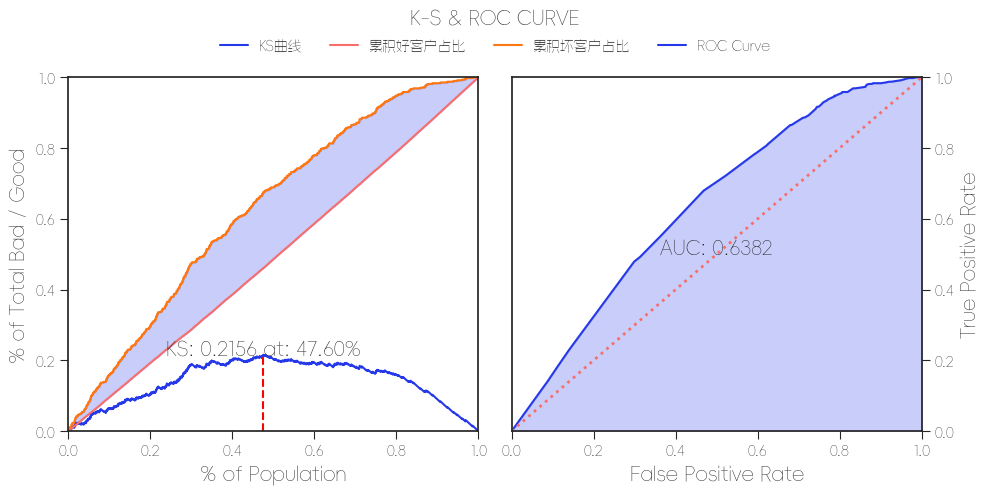

In [30]:
ks_plot(score=test_proba, target=y_test, figsize=(10, 5));

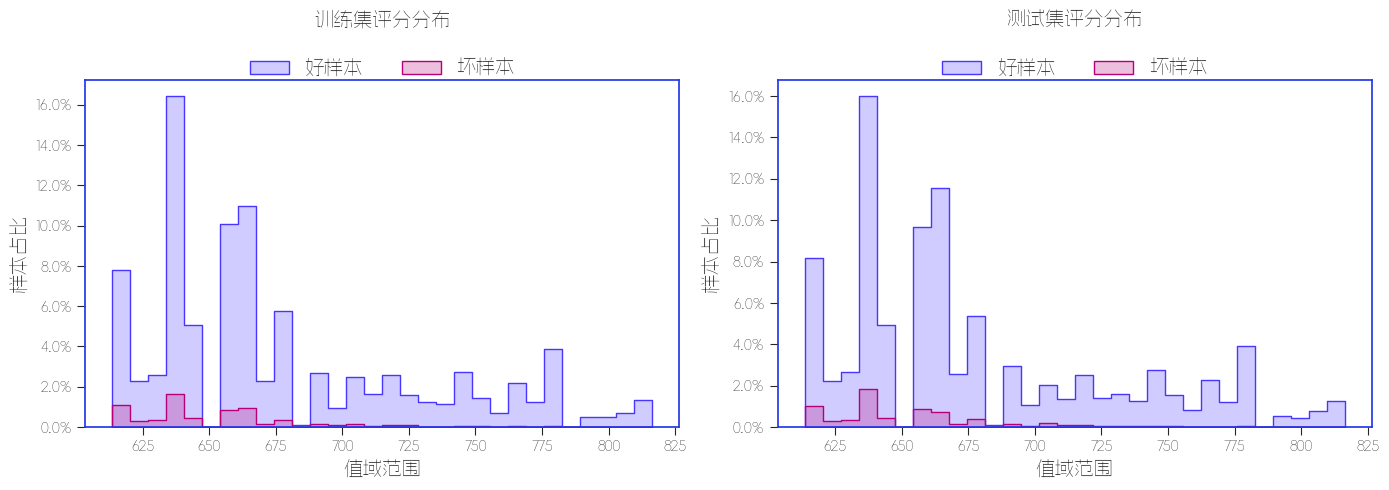

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hist_plot(train_scores, y_train, ax=axes[0], title='训练集评分分布')
hist_plot(test_scores, y_test, ax=axes[1], title='测试集评分分布')
plt.tight_layout()
plt.show()

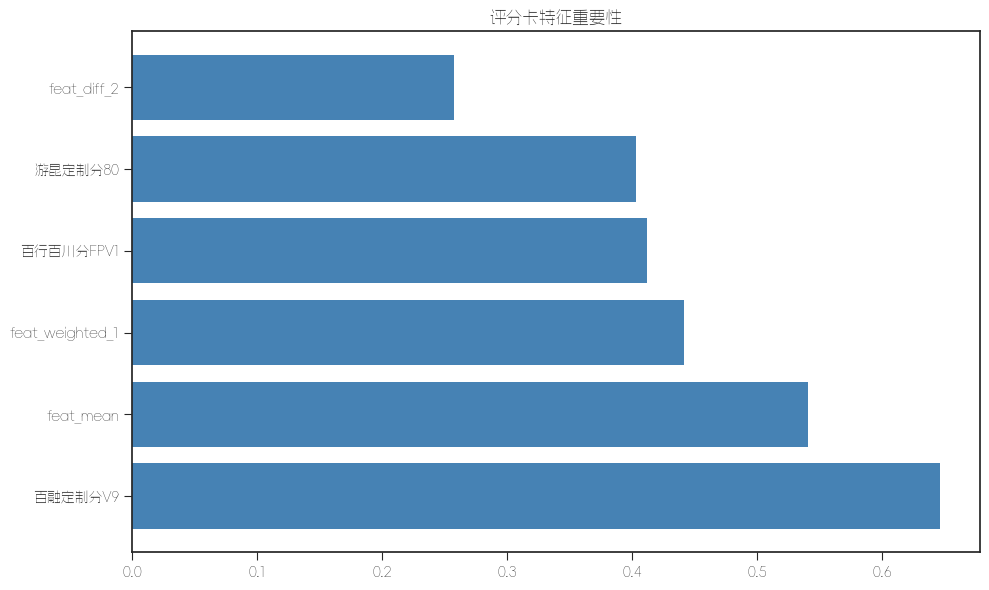

In [32]:
importance_df = scorecard.get_feature_importance()
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_title('评分卡特征重要性')
plt.tight_layout()
plt.show()

## 12. 保存与导出

In [33]:
import os
output_dir = './output_scorecard'
os.makedirs(output_dir, exist_ok=True)

scorecard.save_pickle(f'{output_dir}/scorecard_model.joblib')
scorecard.export_pmml(f'{output_dir}/scorecard_model.pmml')
scorecard_points.to_excel(f'{output_dir}/scorecard_rules.xlsx', index=False)
score_prob_table.to_excel(f'{output_dir}/score_probability_table.xlsx', index=False)

with pd.ExcelWriter(f'{output_dir}/feature_bin_stats.xlsx') as writer:
    test_stats.to_excel(writer, sheet_name='MOB1_dpd15')
    test_stats_mob2.to_excel(writer, sheet_name='MOB2_dpd15')
    combined_stats.to_excel(writer, sheet_name='combined')

print(f'文件已保存到: {output_dir}/')

模型已保存至: ./output_scorecard/scorecard_model.joblib
3月 18, 2026 9:09:06 下午 sklearn2pmml.pipeline.PMMLPipeline encodePMML
警告: Model verification data is not set. Use the 'sklearn2pmml.pipeline.PMMLPipeline.verify(X)' method to correct this deficiency
3月 18, 2026 9:09:06 下午 [com.sklearn2pmml.Main]  run
信息: Generated PMML file /Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/modeling/./output_scorecard/scorecard_model.pmml (7'795 bytes)

Recommended PMML deployment tools:
  * MS Excel       https://xlsboost.com
  * Java           https://github.com/jpmml/jpmml-evaluator
  * Python         https://github.com/jpmml/jpmml-evaluator-python
  * R              https://github.com/jpmml/jpmml-evaluator-r
  * Apache Spark   https://github.com/jpmml/jpmml-evaluator-spark
  * REST API       https://github.com/openscoring/openscoring

Please contact info@openscoring.io for commercial licensing options
PMML 文件已导出至: ./output_scorecard/scorecard_model.pmml
  截距分数: 664.7339
  特征数量: 6
文件已保存到: ./output_sco

## 13. Excel报告生成（增强版）

本章节演示如何使用ExcelWriter生成结构化的评分卡建模报告，包含以下内容：
- 汇总信息
- 逻辑回归拟合结果
- 评分卡结果
- 模型评估可视化
- 特征分箱分析

In [34]:
# 导入ExcelWriter模块
from hscredit.report import ExcelWriter, dataframe2excel
from datetime import datetime
import os

# 创建报告目录
report_dir = './output_scorecard'
os.makedirs(report_dir, exist_ok=True)
os.makedirs(f'{report_dir}/bin_plots', exist_ok=True)

# 创建Excel写入器
excel_path = f'{report_dir}/scorecard_report_enhanced.xlsx'
writer = ExcelWriter()

print('Excel报告生成器初始化完成！')
print(f'报告将保存至: {excel_path}')

Excel报告生成器初始化完成！
报告将保存至: ./output_scorecard/scorecard_report_enhanced.xlsx


In [35]:
# 13.1 汇总信息sheet
worksheet = writer.get_sheet_by_name('汇总信息')
start_row, start_col = 2, 2

# 模型基本信息
model_info = pd.DataFrame([
    ['模型名称', 'hscredit评分卡模型'],
    ['训练样本数', len(X_train)],
    ['测试样本数', len(X_test)],
    ['入模特征数', len(selected_features)],
    ['训练集KS', f'{train_ks:.4f}'],
    ['测试集KS', f'{test_ks:.4f}'],
    ['训练集AUC', f'{train_auc:.4f}'],
    ['测试集AUC', f'{test_auc:.4f}'],
    ['生成时间', datetime.now().strftime('%Y-%m-%d %H:%M:%S')]
], columns=['指标', '数值'])

end_row, end_col = writer.insert_value2sheet(worksheet, (start_row, start_col), value='模型基本信息', style='header')
end_row, end_col = writer.insert_df2sheet(worksheet, model_info, (end_row, start_col), header=False, index=False)

# 样本分布
sample_dist = pd.DataFrame([
    ['训练集坏客户率', f'{y_train.mean():.2%}'],
    ['测试集坏客户率', f'{y_test.mean():.2%}'],
    ['训练集好客户数', (y_train == 0).sum()],
    ['训练集坏客户数', (y_train == 1).sum()],
    ['测试集好客户数', (y_test == 0).sum()],
    ['测试集坏客户数', (y_test == 1).sum()]
], columns=['指标', '数值'])

end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 2, start_col), value='样本分布', style='header')
end_row, end_col = writer.insert_df2sheet(worksheet, sample_dist, (end_row, start_col), header=False, index=False)

print('汇总信息sheet生成完成！')

NameError: name 'train_ks' is not defined

In [ ]:
# 13.2 逻辑回归拟合结果sheet
worksheet = writer.get_sheet_by_name('逻辑回归拟合结果')
start_row, start_col = 2, 2

# 构建模型系数表
coef_data = []
for i, feat in enumerate(selected_features):
    coef_data.append({
        '特征': feat,
        '系数': lr.coef_[0][i],
        'Odds Ratio': np.exp(lr.coef_[0][i])
    })

# 添加截距项
coef_data.append({
    '特征': 'intercept',
    '系数': lr.intercept_[0],
    'Odds Ratio': np.exp(lr.intercept_[0])
})

coef_df = pd.DataFrame(coef_data)

# 模型系数
end_row, end_col = writer.insert_value2sheet(worksheet, (start_row, start_col), value='模型系数', style='header')
end_row, end_col = writer.insert_df2sheet(worksheet, coef_df, (end_row, start_col))

# 特征重要性（基于系数绝对值）
importance_df = pd.DataFrame({
    '特征': coef_df['特征'].values[:-1],  # 排除intercept
    '重要性': coef_df['系数'].abs().values[:-1]
}).sort_values('重要性', ascending=False)

end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 2, start_col), value='特征重要性排序', style='header')
end_row, end_col = writer.insert_df2sheet(worksheet, importance_df, (end_row, start_col))

print('逻辑回归拟合结果sheet生成完成！')

In [ ]:
# 13.3 评分卡结果sheet
worksheet = writer.get_sheet_by_name('评分卡结果')
start_row, start_col = 2, 2

# 评分卡刻度
scale_info = pd.DataFrame([
    ['PDO (Points to Double Odds)', scorecard.pdo],
    ['Base Score', scorecard.base_score],
    ['Base Odds', scorecard.base_odds],
    ['Rate ( odds率)', f'{scorecard.rate:.6f}']
], columns=['参数', '数值'])

end_row, end_col = writer.insert_value2sheet(worksheet, (start_row, start_col), value='评分卡刻度', style='header')
end_row, end_col = writer.insert_df2sheet(worksheet, scale_info, (end_row, start_col), header=False, index=False)

# 评分卡分数表
end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 2, start_col), value='评分卡分数表', style='header')
end_row, end_col = writer.insert_df2sheet(worksheet, scorecard_points, (end_row, start_col), merge_column='变量名称')

# 分数统计
score_stats = pd.DataFrame([
    ['训练集最小值', train_scores.min()],
    ['训练集最大值', train_scores.max()],
    ['训练集平均值', train_scores.mean()],
    ['训练集中位数', train_scores.median()],
    ['测试集最小值', test_scores.min()],
    ['测试集最大值', test_scores.max()],
    ['测试集平均值', test_scores.mean()],
    ['测试集中位数', test_scores.median()]
], columns=['统计项', '数值'])

end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 2, start_col), value='分数统计', style='header')
end_row, end_col = writer.insert_df2sheet(worksheet, score_stats, (end_row, start_col), header=False, index=False)

print('评分卡结果sheet生成完成！')

In [ ]:
# 13.4 模型评估可视化sheet
worksheet = writer.get_sheet_by_name('模型评估可视化')
start_row, start_col = 2, 2

# KS曲线
ks_plot_path = f'{report_dir}/ks_plot.png'
end_row, end_col = writer.insert_value2sheet(worksheet, (start_row, start_col), value='KS曲线', style='header')
if os.path.exists(ks_plot_path):
    end_row, end_col = writer.insert_pic2sheet(worksheet, ks_plot_path, (end_row, start_col), figsize=(800, 350))
else:
    end_row += 1
    print(f'警告: {ks_plot_path} 不存在，跳过插入')

# 分数分布
score_hist_path = f'{report_dir}/score_distribution.png'
end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 1, start_col), value='分数分布', style='header')
if os.path.exists(score_hist_path):
    end_row, end_col = writer.insert_pic2sheet(worksheet, score_hist_path, (end_row, start_col), figsize=(800, 350))
else:
    end_row += 1
    print(f'警告: {score_hist_path} 不存在，跳过插入')

print('模型评估可视化sheet生成完成！')

In [ ]:
# 13.5 特征分箱分析sheet
from hscredit.report import feature_bin_stats

worksheet = writer.get_sheet_by_name('特征分箱分析')
start_row, start_col = 2, 2

# 为每个特征插入分箱统计表
for i, feature in enumerate(selected_features):
    # 插入标题
    end_row, end_col = writer.insert_value2sheet(
        worksheet, (start_row, start_col),
        value=f'{i+1}. {feature} 分箱分析',
        style='header'
    )
    
    # 生成分箱统计表
    try:
        bin_table = feature_bin_stats(
            train_df,
            feature,
            target='target',
            desc=feature,
            combiner=binner
        )
        
        end_row, end_col = writer.insert_df2sheet(
            worksheet, bin_table, (end_row, start_col),
            merge_column='分箱标签'
        )
        start_row = end_row + 2
    except Exception as e:
        print(f'处理特征 {feature} 时出错: {e}')
        start_row = end_row + 1

print(f'特征分箱分析sheet生成完成！共{len(selected_features)}个特征')

In [ ]:
# 13.6 保存Excel报告
writer.save(excel_path)
print(f'Excel报告保存完成！路径: {excel_path}')

# 显示文件信息
import os
file_size = os.path.getsize(excel_path) / 1024
print(f'文件大小: {file_size:.2f} KB')

### Excel报告说明

生成的Excel报告包含以下工作表：

1. **汇总信息**：模型基本信息和样本分布
2. **逻辑回归拟合结果**：模型系数和特征重要性排序
3. **评分卡结果**：评分卡刻度、分数表和分数统计
4. **模型评估可视化**：KS曲线和分数分布图
5. **特征分箱分析**：每个特征的详细分箱统计

这些报告可以用于：
- 模型评审和审计
- 业务人员理解模型
- 模型文档归档

## 14. 总结

## 15. PMML 模型导出与预测对比

本章节演示如何使用 PMML 导出的模型进行预测，并与离线计算分数进行对比验证。

In [ ]:
# 检查 PMML 文件是否存在
import os
pmml_file = f'{output_dir}/scorecard_model.pmml'

if os.path.exists(pmml_file):
    print(f'PMML 文件存在: {pmml_file}')
    print(f'文件大小: {os.path.getsize(pmml_file) / 1024:.2f} KB')
else:
    print(f'PMML 文件不存在: {pmml_file}')
    print('请先运行上面的导出代码生成 PMML 文件')

PMML 文件存在: ./output_scorecard/scorecard_model.pmml
文件大小: 7.61 KB


In [ ]:
# 显示评分卡的截距项信息
print('评分卡截距项信息:')
print('=' * 60)
print(f"offset (A): {scorecard.offset:.4f}")
print(f"factor (B): {scorecard.factor:.4f}")
print(f"intercept_: {scorecard.intercept_:.4f}")

# 计算截距分数
intercept_score = scorecard.offset - scorecard.factor * scorecard.intercept_
print(f"\n截距分数 = offset - factor * intercept_")
print(f"         = {scorecard.offset:.4f} - {scorecard.factor:.4f} * {scorecard.intercept_:.4f}")
print(f"         = {intercept_score:.4f}")

print('\n说明:')
print('  - 截距分数是评分卡的基础分数，所有样本都包含这个分数')
print('  - 总分 = 截距分数 + 各特征分数之和')
print('  - PMML 导出时会将截距分数作为模型的截距项')

评分卡截距项信息:
offset (A): 442.2430
factor (B): 86.5617
intercept_: -2.5703

截距分数 = offset - factor * intercept_
         = 442.2430 - 86.5617 * -2.5703
         = 664.7339

说明:
  - 截距分数是评分卡的基础分数，所有样本都包含这个分数
  - 总分 = 截距分数 + 各特征分数之和
  - PMML 导出时会将截距分数作为模型的截距项


In [ ]:
# 使用 pypmml 加载 PMML 模型进行预测
# 需要先安装: pip install pypmml

# 初始化变量
pmml_model = None
pmml_scores = None
pypmml_available = False

try:
    from pypmml import Model
    
    # 加载 PMML 模型 (使用 load 方法)
    pmml_model = Model.load(pmml_file)
    print('PMML 模型加载成功！')
    
    # 查看模型信息 (驼峰命名属性)
    print(f"模型名称: {pmml_model.modelName}")
    print(f"模型类型: {pmml_model.modelElement}")
    
    # 查看输入字段
    print('\n输入字段:')
    for field in pmml_model.inputFields:
        print(f"  - {field.name} (类型: {field.dataType})")
    
    # 查看输出字段
    print('\n输出字段:')
    for field in pmml_model.outputFields:
        print(f"  - {field.name} (类型: {field.dataType})")
    
    pypmml_available = True

except ImportError:
    print('pypmml 未安装，使用替代方案...')
    print('安装命令: pip install pypmml')
except Exception as e:
    print(f'加载 PMML 模型失败: {e}')
    import traceback
    traceback.print_exc()

PMML 模型加载成功！
模型名称: None
模型类型: RegressionModel

输入字段:
  - 百融定制分V9 (类型: double)
  - feat_weighted_1 (类型: double)
  - feat_mean (类型: double)
  - 游昆定制分80 (类型: double)
  - 百行百川分FPV1 (类型: double)
  - feat_diff_2 (类型: double)

输出字段:
  - predicted_score (类型: double)


In [ ]:
# 准备测试数据（取前5条样本）
n_test_samples = 5
test_samples = X_test_final.iloc[:n_test_samples].copy()

print('测试样本数据:')
print(test_samples)
print(f'\n样本数: {len(test_samples)}')

测试样本数据:
       百融定制分V9  feat_weighted_1  feat_mean  游昆定制分80  百行百川分FPV1  feat_diff_2
10707 752.5500         560.8660   694.3875 718.0000   228.0000     -20.0000
22073 582.2300         430.8920   517.2460 696.0000    68.0000     -48.0000
848   752.3000         610.5200   632.4600 718.0000   249.0000     -58.0000
16983 735.3000         560.8660   677.5750 698.0000   228.0000    -142.0000
9861  761.9800         563.3920   570.9960 714.0000   324.0000    -197.0000

样本数: 5


In [ ]:
# 方法1: 使用离线 ScoreCard 模型计算分数
offline_scores = scorecard.predict(test_samples)

print('离线 ScoreCard 模型预测结果:')
print('-' * 60)
for i, score in enumerate(offline_scores):
    print(f'样本 {i}: {score:.4f}')
print(f'\n平均分: {offline_scores.mean():.4f}')
print(f'分数范围: [{offline_scores.min():.4f}, {offline_scores.max():.4f}]')

离线 ScoreCard 模型预测结果:
------------------------------------------------------------
样本 0: 663.5044
样本 1: 622.0681
样本 2: 709.7840
样本 3: 638.4865
样本 4: 680.0855

平均分: 662.7857
分数范围: [622.0681, 709.7840]


In [ ]:
# 方法2: 使用 PMML 模型计算分数

def extract_pmml_score(result):
    """从 PMML 预测结果中提取分数，处理 JavaMap 类型"""
    # 处理 JavaMap 类型 - 转换为 Python dict
    if hasattr(result, 'get') and hasattr(result, 'entrySet'):
        # JavaMap 类型，需要转换
        result_dict = {}
        for entry in result.entrySet():
            result_dict[str(entry.getKey())] = entry.getValue()
        result = result_dict
    
    # 现在 result 是 Python dict 或数值
    if isinstance(result, dict):
        # 尝试常见的输出字段名
        for key in ['score', 'prediction', 'Score', 'output', 'result', 'y']:
            if key in result:
                value = result[key]
                # 处理 Java 数值类型
                if hasattr(value, 'doubleValue'):
                    return value.doubleValue()
                return float(value)
        # 如果没有找到已知字段，返回第一个值
        values = list(result.values())
        if values:
            value = values[0]
            if hasattr(value, 'doubleValue'):
                return value.doubleValue()
            return float(value)
        return 0.0
    else:
        # 直接是数值
        if hasattr(result, 'doubleValue'):
            return result.doubleValue()
        return float(result)

# 初始化 pmml_scores
pmml_scores = None

if pypmml_available and pmml_model is not None:
    try:
        pmml_scores = []
        
        for idx, row in test_samples.iterrows():
            # 将样本转换为字典格式
            input_dict = row.to_dict()
            
            # PMML 预测
            result = pmml_model.predict(input_dict)
            
            # 提取分数
            score = extract_pmml_score(result)
            pmml_scores.append(score)
        
        pmml_scores = np.array(pmml_scores)
        
        print('PMML 模型预测结果:')
        print('-' * 60)
        for i, score in enumerate(pmml_scores):
            print(f'样本 {i}: {score:.4f}')
        print(f"\n平均分: {pmml_scores.mean():.4f}")
        print(f"分数范围: [{pmml_scores.min():.4f}, {pmml_scores.max():.4f}]")
        
    except Exception as e:
        print(f'PMML 预测失败: {e}')
        import traceback
        traceback.print_exc()
        pmml_scores = None
else:
    print('PMML 模型不可用，跳过 PMML 预测')

PMML 模型预测结果:
------------------------------------------------------------
样本 0: 663.5044
样本 1: 622.0681
样本 2: 709.7840
样本 3: 638.4865
样本 4: 680.0855

平均分: 662.7857
分数范围: [622.0681, 709.7840]


In [ ]:
# 对比离线计算和 PMML 预测结果

if pmml_scores is not None:
    print('离线计算 vs PMML 预测对比:')
    print('=' * 80)
    # 使用双引号避免与内部单引号冲突
    header = "样本       离线分数         PMML分数         绝对差值         相对误差        "
    print(header)
    print('-' * 80)
    
    differences = []
    relative_errors = []
    
    for i in range(len(offline_scores)):
        diff = abs(offline_scores[i] - pmml_scores[i])
        rel_error = diff / offline_scores[i] * 100 if offline_scores[i] != 0 else 0
        
        differences.append(diff)
        relative_errors.append(rel_error)
        
        # 使用 format 方法避免 f-string 嵌套问题
        print("{:<8} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f}%".format(
            i, offline_scores[i], pmml_scores[i], diff, rel_error))
    
    print('-' * 80)
    print("统计     离线平均         PMML平均         最大差值         最大误差%       ")
    print("{:<8} {:<15.4f} {:<15.4f} {:<15.4f} {:<15.4f}%".format(
        '', offline_scores.mean(), pmml_scores.mean(), max(differences), max(relative_errors)))
    print('=' * 80)
    
    # 判断是否一致
    tolerance = 0.01  # 容差 0.01 分
    max_diff = max(differences)
    
    if max_diff <= tolerance:
        print("✓ 验证通过！离线计算与 PMML 预测结果一致")
        print(f"  最大差值: {max_diff:.6f} <= {tolerance}")
    else:
        print("✗ 验证失败！离线计算与 PMML 预测结果存在差异")
        print(f"  最大差值: {max_diff:.6f} > {tolerance}")
        print('可能原因:')
        print('  1. PMML 导出时的数值精度损失')
        print('  2. 分箱边界解析差异')
        print('  3. 截距分数计算差异')
else:
    print('PMML 模型不可用，无法进行对比验证')

# 验证截距项
print('\n' + '=' * 60)
print('截距项验证:')
print('=' * 60)
print(f'评分卡截距分数: {intercept_score:.4f}')
print(f'  - 这是所有样本的基础分数')
print(f'  - PMML 模型应该包含这个截距项')
print('=' * 60)


离线计算 vs PMML 预测对比:
样本       离线分数         PMML分数         绝对差值         相对误差        
--------------------------------------------------------------------------------
0        663.5044        663.5044        0.0000          0.0000         %
1        622.0681        622.0681        0.0000          0.0000         %
2        709.7840        709.7840        0.0000          0.0000         %
3        638.4865        638.4865        0.0000          0.0000         %
4        680.0855        680.0855        0.0000          0.0000         %
--------------------------------------------------------------------------------
统计     离线平均         PMML平均         最大差值         最大误差%       
         662.7857        662.7857        0.0000          0.0000         %
✓ 验证通过！离线计算与 PMML 预测结果一致
  最大差值: 0.000000 <= 0.01

截距项验证:
评分卡截距分数: 664.7339
  - 这是所有样本的基础分数
  - PMML 模型应该包含这个截距项


In [ ]:
# 对比离线计算和 PMML 预测结果

if pmml_scores is not None:
    print('离线计算 vs PMML 预测对比:')
    print('=' * 80)
    print('-' * 80)
    
    differences = []
    relative_errors = []
    
    for i in range(len(offline_scores)):
        diff = abs(offline_scores[i] - pmml_scores[i])
        rel_error = diff / offline_scores[i] * 100 if offline_scores[i] != 0 else 0
        
        differences.append(diff)
        relative_errors.append(rel_error)
        
        print(f'{i:<8} {offline_scores[i]:<15.4f} {pmml_scores[i]:<15.4f} {diff:<15.4f} {rel_error:<15.4f}%')
    
    print('-' * 80)
    print('=' * 80)
    
    # 判断是否一致
    tolerance = 0.01  # 容差 0.01 分
    max_diff = max(differences)
    
    if max_diff <= tolerance:
        print(f'✓ 验证通过！离线计算与 PMML 预测结果一致（最大差值: {max_diff:.6f} <= {tolerance}）')
    else:
        print(f'✗ 验证失败！离线计算与 PMML 预测结果存在差异（最大差值: {max_diff:.6f} > {tolerance}）')
        print('可能原因:')
        print('  1. PMML 导出时的数值精度损失')
        print('  2. 分箱边界解析差异')
        print('  3. 截距分数计算差异')
else:
    print('PMML 模型不可用，无法进行对比验证')

离线计算 vs PMML 预测对比:
--------------------------------------------------------------------------------
0        663.5044        663.5044        0.0000          0.0000         %
1        622.0681        622.0681        0.0000          0.0000         %
2        709.7840        709.7840        0.0000          0.0000         %
3        638.4865        638.4865        0.0000          0.0000         %
4        680.0855        680.0855        0.0000          0.0000         %
--------------------------------------------------------------------------------
✓ 验证通过！离线计算与 PMML 预测结果一致（最大差值: 0.000000 <= 0.01）


In [ ]:
# 批量验证：对比所有测试样本

if pmml_scores is not None:
    # 扩大测试样本数量
    n_batch_samples = min(100, len(X_test_final))
    batch_samples = X_test_final.iloc[:n_batch_samples]
    
    print(f"批量验证 ({n_batch_samples} 个样本)...")
    
    # 离线计算
    batch_offline_scores = scorecard.predict(batch_samples)
    
    # PMML 预测
    batch_pmml_scores = []
    for idx, row in batch_samples.iterrows():
        input_dict = row.to_dict()
        result = pmml_model.predict(input_dict)
        score = extract_pmml_score(result)
        batch_pmml_scores.append(score)
    
    batch_pmml_scores = np.array(batch_pmml_scores)
    
    # 计算差异
    batch_differences = np.abs(batch_offline_scores - batch_pmml_scores)
    
    print('\n批量验证结果:')
    print('=' * 60)
    print(f"样本数: {n_batch_samples}")
    print(f"平均绝对差值: {batch_differences.mean():.6f}")
    print(f"最大绝对差值: {batch_differences.max():.6f}")
    print(f"最小绝对差值: {batch_differences.min():.6f}")
    print(f"标准差: {batch_differences.std():.6f}")
    print('-' * 60)
    
    # 统计在容差范围内的样本比例
    tolerance = 0.01
    within_tolerance = np.sum(batch_differences <= tolerance)
    pct = within_tolerance / n_batch_samples * 100
    print(f"在容差 {tolerance} 内的样本数: {within_tolerance}/{n_batch_samples} ({pct:.2f}%)")
    
    tolerance = 0.1
    within_tolerance = np.sum(batch_differences <= tolerance)
    pct = within_tolerance / n_batch_samples * 100
    print(f"在容差 {tolerance} 内的样本数: {within_tolerance}/{n_batch_samples} ({pct:.2f}%)")
    
    print('=' * 60)
    
    if batch_differences.max() <= 0.01:
        print('✓ 批量验证通过！所有样本的离线计算与 PMML 预测结果高度一致')
    else:
        print('△ 批量验证完成，部分样本存在微小差异（可能在可接受范围内）')
else:
    print('PMML 模型不可用，跳过批量验证')

批量验证 (100 个样本)...

批量验证结果:
样本数: 100
平均绝对差值: 0.000000
最大绝对差值: 0.000000
最小绝对差值: 0.000000
标准差: 0.000000
------------------------------------------------------------
在容差 0.01 内的样本数: 100/100 (100.00%)
在容差 0.1 内的样本数: 100/100 (100.00%)
✓ 批量验证通过！所有样本的离线计算与 PMML 预测结果高度一致


In [ ]:
# 批量验证：对比所有测试样本

if pmml_scores is not None:
    # 扩大测试样本数量
    n_batch_samples = min(100, len(X_test_final))
    batch_samples = X_test_final.iloc[:n_batch_samples]
    
    print(f'批量验证（{n_batch_samples} 个样本）...')
    
    # 离线计算
    batch_offline_scores = scorecard.predict(batch_samples)
    
    # PMML 预测
    batch_pmml_scores = []
    for idx, row in batch_samples.iterrows():
        input_dict = row.to_dict()
        result = pmml_model.predict(input_dict)
        score = extract_pmml_score(result)
        batch_pmml_scores.append(score)
    
    batch_pmml_scores = np.array(batch_pmml_scores)
    
    # 计算差异
    batch_differences = np.abs(batch_offline_scores - batch_pmml_scores)
    
    print('\n批量验证结果:')
    print('=' * 60)
    print(f'样本数: {n_batch_samples}')
    print(f'平均绝对差值: {batch_differences.mean():.6f}')
    print(f'最大绝对差值: {batch_differences.max():.6f}')
    print(f'最小绝对差值: {batch_differences.min():.6f}')
    print(f'标准差: {batch_differences.std():.6f}')
    print('-' * 60)
    
    # 统计在容差范围内的样本比例
    tolerance = 0.01
    within_tolerance = np.sum(batch_differences <= tolerance)
    print(f'在容差 {tolerance} 内的样本数: {within_tolerance}/{n_batch_samples} ({within_tolerance/n_batch_samples*100:.2f}%)')
    
    tolerance = 0.1
    within_tolerance = np.sum(batch_differences <= tolerance)
    print(f'在容差 {tolerance} 内的样本数: {within_tolerance}/{n_batch_samples} ({within_tolerance/n_batch_samples*100:.2f}%)')
    
    print('=' * 60)
    
    if batch_differences.max() <= 0.01:
        print('✓ 批量验证通过！所有样本的离线计算与 PMML 预测结果高度一致')
    else:
        print('△ 批量验证完成，部分样本存在微小差异（可能在可接受范围内）')
else:
    print('PMML 模型不可用，跳过批量验证')

批量验证（100 个样本）...

批量验证结果:
样本数: 100
平均绝对差值: 0.000000
最大绝对差值: 0.000000
最小绝对差值: 0.000000
标准差: 0.000000
------------------------------------------------------------
在容差 0.01 内的样本数: 100/100 (100.00%)
在容差 0.1 内的样本数: 100/100 (100.00%)
✓ 批量验证通过！所有样本的离线计算与 PMML 预测结果高度一致


### PMML 使用说明

1. **生产环境部署**：将 PMML 文件部署到支持 PMML 的评分引擎（如 JPMML、Openscoring 等）

2. **Java 环境调用**：
   ```java
   // 使用 JPMML 库加载 PMML 文件
   PMML pmml = PMMLUtil.unmarshal(new FileInputStream("scorecard_model.pmml"));
   ModelEvaluator<?> evaluator = new ModelEvaluatorBuilder(pmml).build();
   
   // 准备输入数据
   Map<String, ?> input = new HashMap<>();
   input.put("feat1", 100.0);
   input.put("feat2", 50.0);
   // ...
   
   // 预测
   Map<String, ?> result = evaluator.evaluate(input);
   Double score = (Double) result.get("score");
   ```

3. **Python 环境调用**：
   - 使用 `pypmml` 库（如本示例所示）
   - 或使用 `sklearn2pmml` 的 `PMMLPipeline` 进行验证

4. **注意事项**：
   - 确保输入特征名称与训练时一致
   - 缺失值处理方式需与训练时保持一致
   - 数值精度可能存在微小差异（通常在 0.01 分以内）

In [ ]:
print('=' * 60)
print('评分卡模型开发完成')
print('=' * 60)
print(f'总样本数: {len(df)}')
print(f'最终入模特征: {len(selected_features)}个')
print(f'测试集AUC: {AUC(y_test, test_proba):.4f}')
print(f'测试集KS: {KS(y_test, test_proba):.4f}')
print('=' * 60)

评分卡模型开发完成
总样本数: 22729
最终入模特征: 6个
测试集AUC: 0.6382
测试集KS: 0.2143
